Sube una imagen (JPG o PNG)


Saving images.jpg to images.jpg


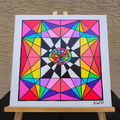


--- EJECUTANDO ALGORITMO GENÉTICO MEJORADO ---
Estancamiento detectado en generación 29 (sin mejora durante 30 gens)
Tiempo total: 42.9 s
Error final (en evaluación progresiva): 0.223522

--- Refinando con Hill-Climbing (alta resolución) ---
Error tras hill-climbing: 0.134053
Renderizando a 375x500 con antialiasing...


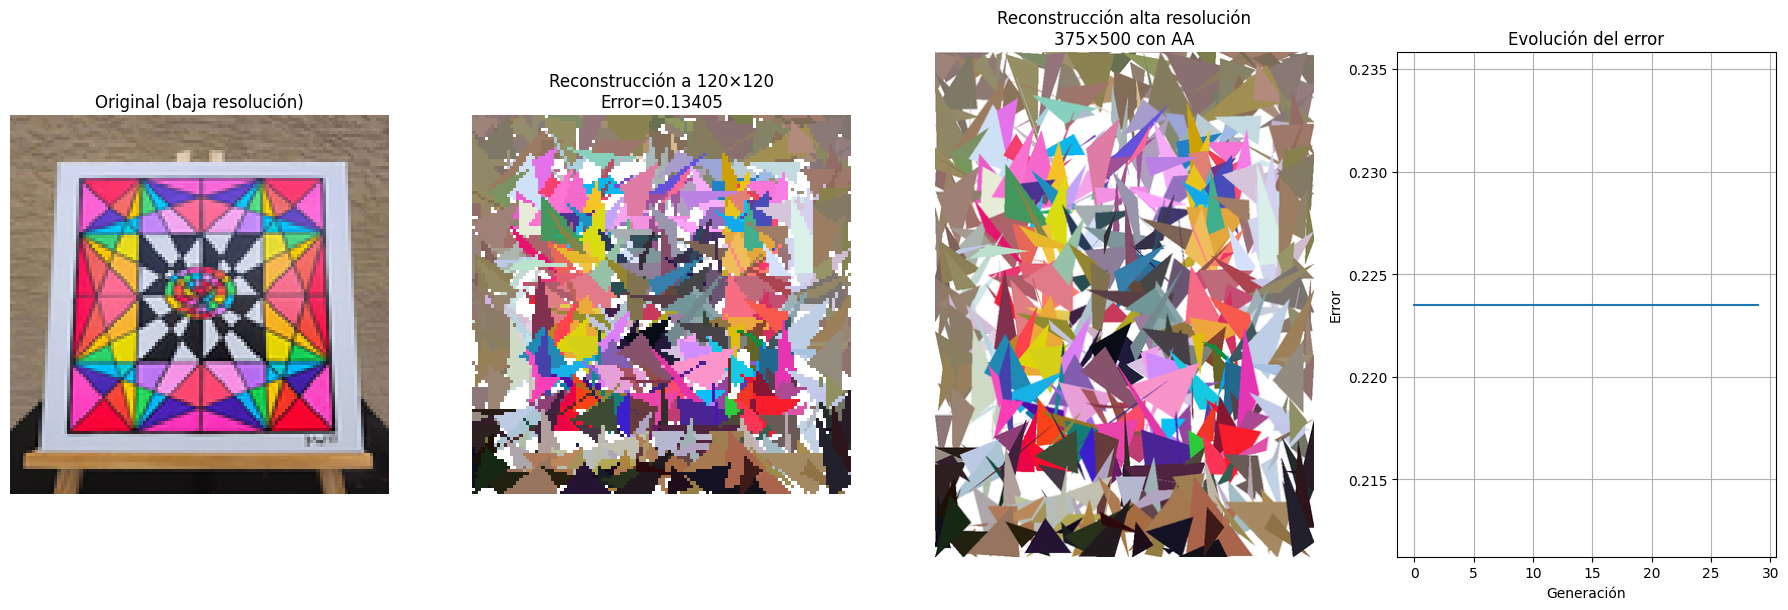

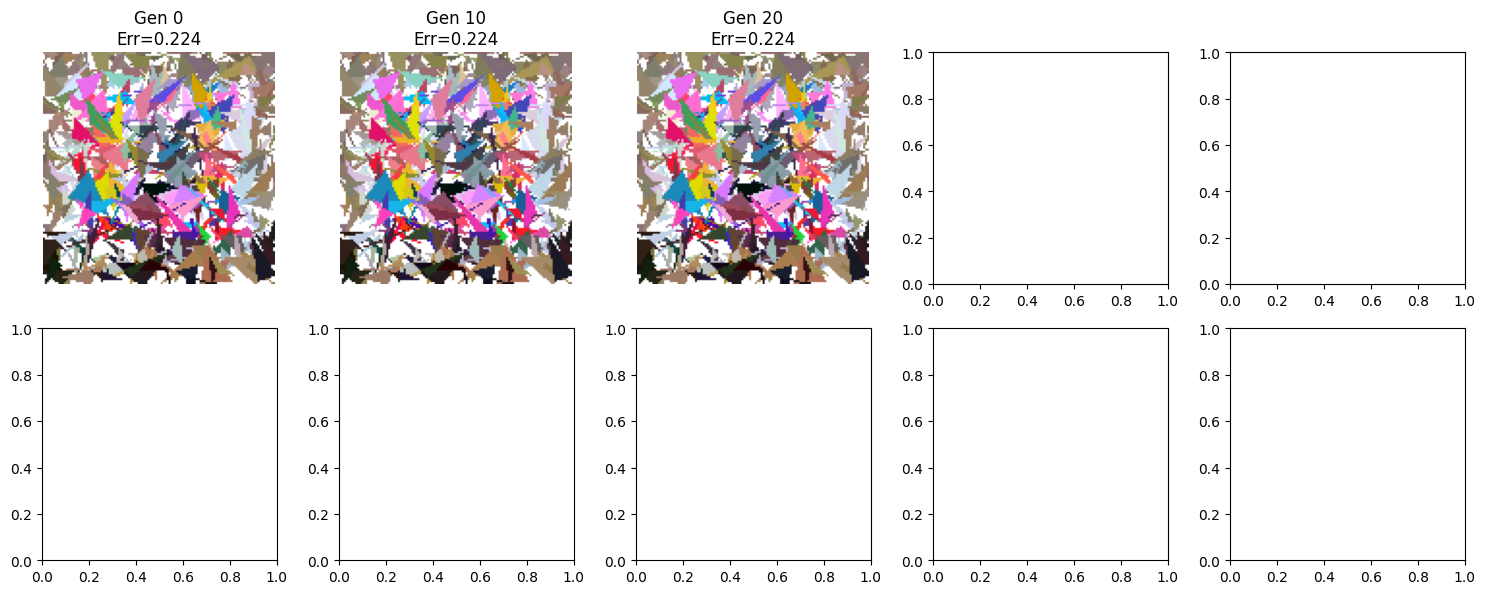


--- Triángulos finales (primeros 10) ---
1: vértices=(0.000,0.000) (0.142,0.001) (0.029,0.061)  color=(0.551,0.458,0.453,1.000)
2: vértices=(0.046,0.000) (0.110,0.079) (0.103,0.027)  color=(0.597,0.504,0.418,1.000)
3: vértices=(0.093,0.013) (0.178,0.011) (0.069,0.074)  color=(0.627,0.512,0.358,1.000)
4: vértices=(0.094,0.094) (0.207,0.097) (0.153,0.000)  color=(0.535,0.468,0.430,0.961)
5: vértices=(0.130,0.003) (0.192,0.106) (0.103,0.027)  color=(0.556,0.532,0.390,0.950)
6: vértices=(0.217,0.000) (0.371,0.021) (0.248,0.028)  color=(0.587,0.591,0.485,0.974)
7: vértices=(0.317,0.040) (0.286,0.000) (0.266,0.029)  color=(0.512,0.357,0.400,1.000)
8: vértices=(0.208,0.000) (0.317,0.005) (0.291,0.034)  color=(0.483,0.547,0.394,0.983)
9: vértices=(0.388,0.026) (0.361,0.000) (0.333,0.007)  color=(0.503,0.465,0.377,0.999)
10: vértices=(0.444,0.000) (0.437,0.000) (0.371,0.060)  color=(0.504,0.324,0.384,0.989)

... y 490 triángulos más.

Imagen final guardada como 'reconstruccion_final.png'


In [ ]:
# -*- coding: utf-8 -*-
"""TP2_AG_Triangulos_500_MEJORADO.ipynb

Algoritmo genético mejorado para aproximar imágenes con N triángulos.
Incluye:
- Inicialización estructurada con colores reales de la imagen
- Crossover por bloques completos de triángulos
- Mutación adaptativa (multigen, vértices y color)
- Evaluación progresiva (resolución creciente)
- Elitismo real
- Refinamiento local (hill-climbing) al final
- Renderizado final en alta resolución con antialiasing
- Selección y supervivencia múltiples (todas las originales)
"""

!pip install pillow numpy matplotlib scikit-image -q

import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.metrics import structural_similarity as ssim
import random
import copy
import time
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------------------
# Renderizado y métricas
# ----------------------------------------------------------------------

def renderizar(triangulos, size=(100,100), fondo=(255,255,255,255)):
    """Renderiza los triángulos en una imagen del tamaño dado (sin antialiasing)."""
    img = Image.new('RGBA', size, fondo)
    draw = ImageDraw.Draw(img, 'RGBA')
    for pts, color in triangulos:
        x1,y1,x2,y2,x3,y3 = pts
        w,h = size
        p = [(int(x1*w), int(y1*h)),
             (int(x2*w), int(y2*h)),
             (int(x3*w), int(y3*h))]
        r,g,b,a = [int(c*255) for c in color]
        draw.polygon(p, fill=(r,g,b,a))
    return img

def renderizar_alta_resolucion(triangulos, size, supersample=2):
    """
    Renderiza con antialiasing mediante supersampling.
    - Dibuja a size * supersample y reduce con LANCZOS.
    """
    if supersample <= 1:
        return renderizar(triangulos, size)
    big_size = (size[0]*supersample, size[1]*supersample)
    big_img = renderizar(triangulos, big_size)
    # Reducir con LANCZOS (antialiasing de alta calidad)
    return big_img.resize(size, Image.LANCZOS)

def mse(im1, im2):
    a1 = np.array(im1.convert('RGB')).astype(np.float32)/255.0
    a2 = np.array(im2.convert('RGB')).astype(np.float32)/255.0
    return np.mean((a1-a2)**2)

def gradiente(im):
    sx = ndimage.sobel(im, axis=0)
    sy = ndimage.sobel(im, axis=1)
    return np.hypot(sx, sy)

def fitness_combinado(im_orig, im_rec, peso_bordes=0.15, peso_ssim=0.15):
    err_color = mse(im_orig, im_rec)

    gray_orig = np.array(im_orig.convert('L')).astype(np.float32)/255.0
    gray_rec = np.array(im_rec.convert('L')).astype(np.float32)/255.0

    g_orig = gradiente(gray_orig)
    g_rec = gradiente(gray_rec)
    g_orig = g_orig / (g_orig.max() + 1e-8)
    g_rec = g_rec / (g_rec.max() + 1e-8)
    err_bordes = np.mean((g_orig - g_rec)**2)

    try:
        ssim_val = ssim(gray_orig, gray_rec, data_range=1.0, win_size=7)
        err_ssim = 1.0 - ssim_val
    except:
        err_ssim = 0.0

    err_total = err_color + peso_bordes * err_bordes + peso_ssim * err_ssim
    return err_total

# ----------------------------------------------------------------------
# Generación de triángulos estructurados con colores desde la imagen
# ----------------------------------------------------------------------

def generar_triangulos_grilla(n, target, perturbacion=0.12):
    """
    Genera n triángulos distribuidos en grilla.
    Cada triángulo cubre la mayor parte de su celda (se solapan ligeramente).
    El color se toma del centro de la celda en la imagen objetivo.
    """
    w, h = target.size
    img = np.array(target.convert('RGB')).astype(np.float32) / 255.0

    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))

    triangulos = []

    for i in range(rows):
        for j in range(cols):
            if len(triangulos) >= n:
                break

            cx = (j + 0.5) / cols
            cy = (i + 0.5) / rows
            cell_w = 1.0 / cols
            cell_h = 1.0 / rows

            # Vértices con perturbación, pero cubriendo casi toda la celda
            # Usamos 0.45 para que el triángulo ocupe ~90% del ancho/alto
            x1 = cx - cell_w*0.45 + np.random.uniform(-perturbacion*cell_w, perturbacion*cell_w)
            y1 = cy - cell_h*0.45 + np.random.uniform(-perturbacion*cell_h, perturbacion*cell_h)
            x2 = cx + cell_w*0.45 + np.random.uniform(-perturbacion*cell_w, perturbacion*cell_w)
            y2 = cy - cell_h*0.45 + np.random.uniform(-perturbacion*cell_h, perturbacion*cell_h)
            x3 = cx + np.random.uniform(-perturbacion*cell_w, perturbacion*cell_w)
            y3 = cy + cell_h*0.45 + np.random.uniform(-perturbacion*cell_h, perturbacion*cell_h)

            pts = [np.clip(x1,0,1), np.clip(y1,0,1),
                   np.clip(x2,0,1), np.clip(y2,0,1),
                   np.clip(x3,0,1), np.clip(y3,0,1)]

            # Color tomado de la imagen en el centro de la celda
            px = min(int(cx * w), w-1)
            py = min(int(cy * h), h-1)
            color = img[py, px].tolist() + [1.0]  # alfa fijo = 1 (opaco)

            triangulos.append((pts, color))

    # Completar con aleatorios si faltan
    while len(triangulos) < n:
        pts = list(np.random.uniform(0,1,6))
        color = list(np.random.uniform(0,1,3)) + [1.0]
        triangulos.append((pts, color))

    return triangulos[:n]

# ----------------------------------------------------------------------
# ALGORITMO GENÉTICO MEJORADO (con todas las mejoras)
# ----------------------------------------------------------------------

class AG_Mejorado:
    def __init__(self, target, ntri, pop=50, gens=200, pm=0.20, pc=0.80,
                 elite=5, stop_error=0.001, modo_supervivencia='exclusiva',
                 paciencia=25, eval_size_inicial=40, eval_size_final=100):
        """
        target: imagen objetivo (PIL Image)
        ntri: número de triángulos (K)
        pop: tamaño de la población
        gens: número máximo de generaciones
        pm: probabilidad de mutación por gen
        pc: probabilidad de cruza
        elite: número de individuos élite (se preservan intactos)
        modo_supervivencia: 'aditiva' o 'exclusiva'
        paciencia: generaciones sin mejora para detener
        eval_size_inicial/final: rango de resolución de evaluación progresiva
        """
        self.target = target
        self.K = ntri
        self.N = pop
        self.G = gens
        self.pm = pm
        self.pc = pc
        self.elite = elite
        self.stop_error = stop_error
        self.paciencia = paciencia
        self.w, self.h = target.size
        self.L = ntri * 10
        self.pop = []
        self.fits = []
        self.best_fit = float('inf')
        self.best_ind = None
        self.best_err = float('inf')
        self.hist = []
        self.mejor_cada = []

        # Evaluación progresiva
        self.eval_size_inicial = eval_size_inicial
        self.eval_size_final = eval_size_final
        self.current_eval_size = eval_size_inicial
        self.target_small_cache = {}  # caché de imágenes redimensionadas

        # Modos de selección y supervivencia
        self.modo_supervivencia = modo_supervivencia
        self.metodo_seleccion = 'torneo_det'
        self.tournament_size = 3
        self.tournament_prob = 0.8
        self.boltzmann_temp = 1.0
        self.boltzmann_temp_min = 0.1

        self.n_random = 2  # inyección de aleatorios

    # --------------------------------------------------------------
    # MÉTODOS DE SELECCIÓN (6 métodos + 2 variantes de torneo)
    # --------------------------------------------------------------

    def seleccionar(self, k):
        if self.metodo_seleccion == 'elite':
            return self.sel_elite(k)
        elif self.metodo_seleccion == 'ruleta':
            return self.sel_ruleta(k)
        elif self.metodo_seleccion == 'universal':
            return self.sel_universal(k)
        elif self.metodo_seleccion == 'boltzmann':
            return self.sel_boltzmann(k)
        elif self.metodo_seleccion == 'ranking':
            return self.sel_ranking(k)
        elif self.metodo_seleccion == 'torneo_det':
            return self.sel_torneo_det(k)
        elif self.metodo_seleccion == 'torneo_prob':
            return self.sel_torneo_prob(k)
        else:
            raise ValueError("Método de selección no reconocido")

    def set_seleccion(self, metodo, **kwargs):
        self.metodo_seleccion = metodo
        if metodo == 'torneo_det':
            self.tournament_size = kwargs.get('t_size', 3)
        elif metodo == 'torneo_prob':
            self.tournament_size = kwargs.get('t_size', 3)
            self.tournament_prob = kwargs.get('t_prob', 0.8)
        elif metodo == 'boltzmann':
            self.boltzmann_temp = kwargs.get('temp', 1.0)
            self.boltzmann_temp_min = kwargs.get('temp_min', 0.1)

    def sel_elite(self, k):
        idx = np.argsort(self.fits)[:k]
        return [self.pop[i] for i in idx]

    def sel_ruleta(self, k):
        aptitudes = 1.0 / (np.array(self.fits) + 1e-10)
        probs = aptitudes / aptitudes.sum()
        elegidos = []
        for _ in range(k):
            r = np.random.rand()
            acum = 0.0
            for i, p in enumerate(probs):
                acum += p
                if r <= acum:
                    elegidos.append(self.pop[i])
                    break
        return elegidos

    def sel_universal(self, k):
        aptitudes = 1.0 / (np.array(self.fits) + 1e-10)
        probs = aptitudes / aptitudes.sum()
        r = np.random.rand() / k
        elegidos = []
        acum = 0.0
        j = 0
        for _ in range(k):
            while r > acum:
                acum += probs[j]
                j = (j + 1) % len(probs)
            elegidos.append(self.pop[j-1])
            r += 1.0 / k
        return elegidos

    def sel_boltzmann(self, k, gen=None):
        temp = max(self.boltzmann_temp_min,
                   self.boltzmann_temp * (1.0 - gen/self.G) if gen is not None else self.boltzmann_temp)
        fits = np.array(self.fits)
        max_fit = fits.max()
        exp_vals = np.exp(-(fits - max_fit) / (temp + 1e-10))
        probs = exp_vals / exp_vals.sum()
        elegidos = []
        for _ in range(k):
            r = np.random.rand()
            acum = 0.0
            for i, p in enumerate(probs):
                acum += p
                if r <= acum:
                    elegidos.append(self.pop[i])
                    break
        return elegidos

    def sel_ranking(self, k, presion=1.5):
        sorted_idx = np.argsort(self.fits)
        N = len(self.pop)
        ranks = np.arange(N, 0, -1)
        p = presion / N
        probs = (2 - p) / N + 2 * (ranks - 1) * (p - 1) / (N * (N - 1)) if N > 1 else np.ones(N)
        probs = np.maximum(probs, 0)
        probs = probs / probs.sum()
        elegidos = []
        for _ in range(k):
            r = np.random.rand()
            acum = 0.0
            for i, idx in enumerate(sorted_idx):
                acum += probs[i]
                if r <= acum:
                    elegidos.append(self.pop[idx])
                    break
        return elegidos

    def sel_torneo_det(self, k):
        elegidos = []
        for _ in range(k):
            idx = np.random.choice(len(self.pop), self.tournament_size, replace=False)
            best = idx[np.argmin([self.fits[i] for i in idx])]
            elegidos.append(self.pop[best])
        return elegidos

    def sel_torneo_prob(self, k):
        elegidos = []
        for _ in range(k):
            idx = np.random.choice(len(self.pop), self.tournament_size, replace=False)
            idx_ord = sorted(idx, key=lambda i: self.fits[i])
            if np.random.rand() < self.tournament_prob:
                elegidos.append(self.pop[idx_ord[0]])
            else:
                elegidos.append(self.pop[idx_ord[1]])
        return elegidos

    # --------------------------------------------------------------
    # MÉTODOS DE SUPERVIVENCIA (Aditiva y Exclusiva)
    # --------------------------------------------------------------

    def sobrevivir(self, padres, hijos):
        if self.modo_supervivencia == 'aditiva':
            pool = padres + hijos
            fits_pool = []
            for ind in pool:
                fits_pool.append(self.eval_ind(ind))
            idx_ord = np.argsort(fits_pool)
            nueva_pop = [pool[i] for i in idx_ord[:self.N]]
            return nueva_pop

        elif self.modo_supervivencia == 'exclusiva':
            fits_hijos = [self.eval_ind(ind) for ind in hijos]
            idx_ord = np.argsort(fits_hijos)
            if len(hijos) < self.N:
                padres_ord = sorted(zip(self.fits, self.pop), key=lambda x: x[0])
                hijos_set = set(tuple(ind) for ind in hijos)
                complemento = []
                for fit, ind in padres_ord:
                    if tuple(ind) not in hijos_set and len(complemento) < self.N - len(hijos):
                        complemento.append(ind)
                nueva_pop = [hijos[i] for i in idx_ord[:min(self.N, len(hijos))]] + complemento
                return nueva_pop[:self.N]
            else:
                return [hijos[i] for i in idx_ord[:self.N]]
        else:
            raise ValueError("Modo de supervivencia no reconocido (use 'aditiva' o 'exclusiva')")

    # --------------------------------------------------------------
    # CONVERSIÓN GENES ↔ TRIÁNGULOS
    # --------------------------------------------------------------

    def genes_a_triangulos(self, genes):
        out = []
        for i in range(self.K):
            start = i*10
            coords = genes[start:start+6].tolist()
            color = genes[start+6:start+10].tolist()
            out.append((coords, color))
        return out

    def triangulos_a_genes(self, triangulos):
        genes = []
        for pts, color in triangulos:
            genes.extend(pts)
            genes.extend(color)
        return np.array(genes)

    # --------------------------------------------------------------
    # INICIALIZACIÓN ESTRUCTURADA
    # --------------------------------------------------------------

    def init_pop_estructurada(self):
        base_tri = generar_triangulos_grilla(self.K, self.target, perturbacion=0.12)
        base_genes = self.triangulos_a_genes(base_tri)
        for i in range(self.N):
            ind = base_genes.copy()
            # Pequeña perturbación inicial para diversidad
            ruido = np.random.normal(0, 0.05, self.L)
            ind = np.clip(ind + ruido, 0, 1)
            self.pop.append(ind)
        self.eval_pop()

    # --------------------------------------------------------------
    # EVALUACIÓN DE FITNESS (con resolución variable)
    # --------------------------------------------------------------

    def get_target_resized(self, size):
        """Devuelve la imagen objetivo redimensionada al tamaño dado (con caché)."""
        key = size
        if key not in self.target_small_cache:
            self.target_small_cache[key] = self.target.resize((size, size), Image.LANCZOS)
        return self.target_small_cache[key]

    def eval_ind(self, genes, size=None):
        """Evalúa un individuo a la resolución dada (si None, usa self.current_eval_size)."""
        if size is None:
            size = self.current_eval_size
        tri = self.genes_a_triangulos(genes)
        target_small = self.get_target_resized(size)
        rendered = renderizar(tri, size=(size, size))
        err = fitness_combinado(target_small, rendered)
        return err

    def eval_pop(self):
        self.fits = []
        for ind in self.pop:
            e = self.eval_ind(ind)
            self.fits.append(e)
        idx = np.argmin(self.fits)
        if self.fits[idx] < self.best_fit:
            self.best_fit = self.fits[idx]
            self.best_ind = copy.deepcopy(self.pop[idx])
            self.best_err = self.fits[idx]

    # --------------------------------------------------------------
    # OPERADORES DE CRUZA (por bloques de triángulos)
    # --------------------------------------------------------------

    def cx_triangular(self, a, b):
        """Crossover por bloques completos de triángulos (10 genes cada uno)."""
        c1 = a.copy()
        c2 = b.copy()

        n_bloques = np.random.randint(1, max(2, self.K // 4))
        indices = np.random.choice(self.K, n_bloques, replace=False)

        for t in indices:
            start = t * 10
            end = start + 10
            c1[start:end] = b[start:end]
            c2[start:end] = a[start:end]

        return c1, c2

    # --------------------------------------------------------------
    # OPERADORES DE MUTACIÓN (adaptativos)
    # --------------------------------------------------------------

    def mut_multigen_adaptativo(self, ind, gen, maxgenes=12):
        """Mutación de múltiples genes con sigma decreciente."""
        sigma = 0.15 * (1.0 - gen/self.G) + 0.02
        if np.random.rand() < self.pm:
            n = np.random.randint(1, maxgenes+1)
            idxs = np.random.choice(self.L, n, replace=False)
            for idx in idxs:
                delta = np.random.normal(0, sigma)
                ind[idx] = np.clip(ind[idx] + delta, 0, 1)
        return ind

    def mutar_vertices_adaptativo(self, ind, gen):
        """Mutación específica de coordenadas de un triángulo."""
        sigma = 0.10 * (1.0 - gen/self.G) + 0.01
        if np.random.rand() < self.pm * 0.5:
            t_idx = np.random.randint(0, self.K)
            start = t_idx * 10
            for i in range(6):
                idx = start + i
                delta = np.random.normal(0, sigma)
                ind[idx] = np.clip(ind[idx] + delta, 0, 1)
        return ind

    def mutar_color_adaptativo(self, ind, gen):
        """Mutación específica de colores de un triángulo."""
        sigma = 0.10 * (1.0 - gen/self.G) + 0.01
        if np.random.rand() < self.pm * 0.5:
            t_idx = np.random.randint(0, self.K)
            start = t_idx * 10 + 6
            for i in range(3):
                idx = start + i
                delta = np.random.normal(0, sigma)
                ind[idx] = np.clip(ind[idx] + delta, 0, 1)
        return ind

    # --------------------------------------------------------------
    # REFINAMIENTO LOCAL (Hill-Climbing)
    # --------------------------------------------------------------

    def hill_climbing(self, individuo, iteraciones=2, paso_inicial=0.05, size_eval=None):
        """
        Refinamiento local: perturba cada gen y acepta si mejora.
        Se ejecuta a la resolución final (size_eval) o a self.current_eval_size.
        """
        if size_eval is None:
            size_eval = self.current_eval_size

        # Aseguramos que size_eval sea al menos 80 para detalle
        size_eval = max(size_eval, 80)

        mejor = individuo.copy()
        mejor_err = self.eval_ind(mejor, size=size_eval)

        for _ in range(iteraciones):
            # Recorremos todos los genes en orden aleatorio
            orden = np.random.permutation(self.L)
            for idx in orden:
                # Probar hacia arriba y hacia abajo
                for signo in [-1, 1]:
                    candidato = mejor.copy()
                    delta = np.random.uniform(0, paso_inicial) * signo
                    candidato[idx] = np.clip(candidato[idx] + delta, 0, 1)
                    err_cand = self.eval_ind(candidato, size=size_eval)
                    if err_cand < mejor_err:
                        mejor = candidato
                        mejor_err = err_cand
                        break  # salimos del bucle de signos si mejoró
            # Reducimos el paso para la siguiente iteración
            paso_inicial *= 0.5

        return mejor, mejor_err

    # --------------------------------------------------------------
    # EJECUCIÓN PRINCIPAL (con evaluación progresiva, elitismo, etc.)
    # --------------------------------------------------------------

    def run(self):
        self.init_pop_estructurada()
        self.hist = []
        self.mejor_cada = []
        t0 = time.time()

        sin_mejora = 0
        ultimo_mejor = self.best_fit

        # Evolución de la resolución de evaluación
        eval_sizes = np.linspace(self.eval_size_inicial, self.eval_size_final, self.G, dtype=int)

        for gen in range(self.G):
            # Actualizar resolución de evaluación
            self.current_eval_size = eval_sizes[gen]

            # 1. Selección de padres (restando élites)
            num_padres = self.N - self.elite
            if num_padres % 2 != 0:
                num_padres += 1
            padres = self.seleccionar(num_padres)

            # 2. Generación de hijos
            hijos = []
            while len(hijos) < self.N - self.elite - self.n_random:
                p1, p2 = random.sample(padres, 2)
                if np.random.rand() < self.pc:
                    c1, c2 = self.cx_triangular(p1, p2)
                else:
                    c1, c2 = p1.copy(), p2.copy()

                c1 = self.mut_multigen_adaptativo(c1, gen)
                c2 = self.mut_multigen_adaptativo(c2, gen)
                c1 = self.mutar_vertices_adaptativo(c1, gen)
                c2 = self.mutar_vertices_adaptativo(c2, gen)
                c1 = self.mutar_color_adaptativo(c1, gen)
                c2 = self.mutar_color_adaptativo(c2, gen)

                hijos.append(c1)
                if len(hijos) < self.N - self.elite - self.n_random:
                    hijos.append(c2)

            # 3. Inyección de individuos aleatorios (diversidad)
            for _ in range(self.n_random):
                nuevo = np.random.uniform(0, 1, self.L)
                hijos.append(nuevo)

            # 4. Supervivencia (ya incluye evaluación de hijos)
            nueva_pop = self.sobrevivir(padres, hijos)
            self.pop = nueva_pop
            self.eval_pop()  # Actualiza fits y best

            # 5. Elitismo: asegurar que el mejor individuo esté en la población
            #    (si no está ya, lo reemplazamos por el peor)
            mejor_actual = self.best_ind
            if mejor_actual is not None:
                # Verificar si el mejor está en la población (por identidad)
                presente = any(np.array_equal(mejor_actual, ind) for ind in self.pop)
                if not presente:
                    # Reemplazar el peor individuo
                    peor_idx = np.argmax(self.fits)
                    self.pop[peor_idx] = mejor_actual.copy()
                    # Re-evaluar ese individuo para actualizar fits
                    self.fits[peor_idx] = self.eval_ind(self.pop[peor_idx])

            # 6. Registro
            self.hist.append(self.best_fit)
            if gen % 10 == 0:
                self.mejor_cada.append((gen, self.best_fit, copy.deepcopy(self.best_ind)))

            # 7. Actualizar temperatura para Boltzmann
            if self.metodo_seleccion == 'boltzmann':
                self.boltzmann_temp = max(self.boltzmann_temp_min,
                                          self.boltzmann_temp * (1.0 - gen/self.G))

            # 8. Criterios de parada
            if self.best_fit < self.stop_error:
                print(f"¡Error mínimo alcanzado en generación {gen}!")
                break

            if self.best_fit < ultimo_mejor - 1e-6:
                ultimo_mejor = self.best_fit
                sin_mejora = 0
            else:
                sin_mejora += 1

            if sin_mejora >= self.paciencia:
                print(f"Estancamiento detectado en generación {gen} (sin mejora durante {self.paciencia} gens)")
                break

        print(f"Tiempo total: {time.time()-t0:.1f} s")
        return self.best_ind, self.best_fit, self.hist, self.mejor_cada


# ----------------------------------------------------------------------
# EJECUCIÓN Y DEMOSTRACIÓN (Colab)
# ----------------------------------------------------------------------

print("Sube una imagen (JPG o PNG)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
img_original = Image.open(filename).convert('RGB')

# Para la evolución usamos una resolución moderada (velocidad vs calidad)
TARGET_SIZE = 120
target = img_original.resize((TARGET_SIZE, TARGET_SIZE), Image.LANCZOS)
display(target)

# Parámetros (ajustables)
K = 500              # Número de triángulos
N = 50               # Tamaño de población
G = 200              # Generaciones
PM = 0.20            # Prob. de mutación (aumentada)
PC = 0.80            # Prob. de cruza
ELITE = 5            # Número de élites
STOP_ERROR = 0.001
PACiencia = 30

print("\n--- EJECUTANDO ALGORITMO GENÉTICO MEJORADO ---")
ag = AG_Mejorado(target, K, pop=N, gens=G, pm=PM, pc=PC,
                 elite=ELITE, stop_error=STOP_ERROR,
                 modo_supervivencia='exclusiva',  # o 'aditiva'
                 paciencia=PACiencia,
                 eval_size_inicial=40, eval_size_final=100)

# Selección: puedes cambiar a 'ranking', 'torneo_det', 'ruleta', etc.
ag.set_seleccion('ranking', presion=1.5)

best, err, hist, mejor_cada = ag.run()
print(f"Error final (en evaluación progresiva): {err:.6f}")

# --- REFINAMIENTO LOCAL (Hill-Climbing) a alta resolución ---
print("\n--- Refinando con Hill-Climbing (alta resolución) ---")
# Usamos la última resolución de evaluación (100) para el pulido
best_refinado, err_refinado = ag.hill_climbing(best, iteraciones=2, paso_inicial=0.03, size_eval=100)
print(f"Error tras hill-climbing: {err_refinado:.6f}")

# --- RENDERIZADO FINAL EN ALTA RESOLUCIÓN CON ANTIALIASING ---
# Usamos la resolución original de la imagen subida (o un máximo razonable)
# Si la imagen es muy grande, limitamos a 500x500 para no saturar
max_dim = 500
w_orig, h_orig = img_original.size
if max(w_orig, h_orig) > max_dim:
    factor = max_dim / max(w_orig, h_orig)
    final_size = (int(w_orig * factor), int(h_orig * factor))
else:
    final_size = (w_orig, h_orig)

print(f"Renderizando a {final_size[0]}x{final_size[1]} con antialiasing...")
tri_final = ag.genes_a_triangulos(best_refinado)
reconstructed_high = renderizar_alta_resolucion(tri_final, size=final_size, supersample=2)

# También renderizamos a la resolución de evolución para comparar
reconstructed_eval = renderizar(tri_final, size=(TARGET_SIZE, TARGET_SIZE))

# --- VISUALIZACIÓN ---
plt.figure(figsize=(18,6))

plt.subplot(1,4,1)
plt.imshow(target)
plt.title("Original (baja resolución)")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(reconstructed_eval)
plt.title(f"Reconstrucción a {TARGET_SIZE}×{TARGET_SIZE}\nError={err_refinado:.5f}")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(reconstructed_high)
plt.title(f"Reconstrucción alta resolución\n{final_size[0]}×{final_size[1]} con AA")
plt.axis('off')

plt.subplot(1,4,4)
plt.plot(hist)
plt.title("Evolución del error")
plt.xlabel("Generación")
plt.ylabel("Error")
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Evolución intermedia ---
if len(mejor_cada) > 1:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i, (gen, e, ind) in enumerate(mejor_cada[:10]):
        r, c = i//5, i%5
        tri_tmp = ag.genes_a_triangulos(ind)
        img_tmp = renderizar(tri_tmp, size=(TARGET_SIZE, TARGET_SIZE))
        axes[r, c].imshow(img_tmp)
        axes[r, c].set_title(f"Gen {gen}\nErr={e:.3f}")
        axes[r, c].axis('off')
    plt.tight_layout()
    plt.show()

print("\n--- Triángulos finales (primeros 10) ---")
for i, (pts, col) in enumerate(tri_final[:10]):
    print(f"{i+1}: vértices=({pts[0]:.3f},{pts[1]:.3f}) ({pts[2]:.3f},{pts[3]:.3f}) ({pts[4]:.3f},{pts[5]:.3f})  color=({col[0]:.3f},{col[1]:.3f},{col[2]:.3f},{col[3]:.3f})")

print(f"\n... y {len(tri_final)-10} triángulos más.")

# Opcional: guardar la imagen final
reconstructed_high.save("reconstruccion_final.png")
print("\nImagen final guardada como 'reconstruccion_final.png'")